In [1]:
from Aplha_n_methods import Alpha_N_calc as an
from Geometry_methods import Geometry_helper as gh

from scipy.optimize import curve_fit
import numpy as np
import openmc
import matplotlib.pyplot as plt


In [2]:
#Getting material 
mats = openmc.Materials.from_xml('materials.xml')

energy span 3500 5000
Waiting for SRModule to produce output...
end of file
parameters and there error
2.86e+07 ± 1e+06
3.45e-06 ± 3e-07
-0.752 ± 0.3


/tmp/ipykernel_1472/200351833.py:13: RuntimeWarning: invalid value encountered in log
  return A*np.log(B*E)/E + C


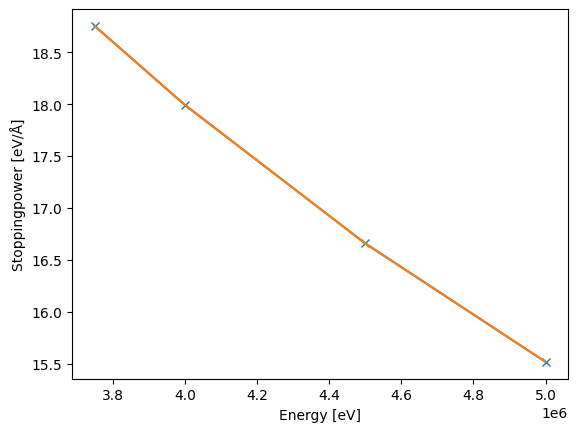

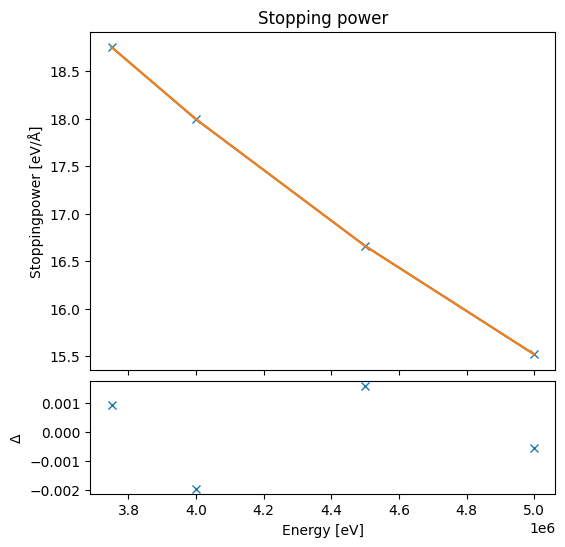

In [3]:
fuel_name= 'Fuel_A'
mat = gh.get_material_by_name(fuel_name,mats)
energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=3500,E_max=5000,new_file=False)

fig,ax = plt.subplots()
ax.plot(energies,stopping_powers,'x-',label=fuel_name)
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('Stoppingpower [eV/Å]')


def bethe_tail(E, A, B, C):
    E=np.array(E)
    return A*np.log(B*E)/E + C
def uncertainties_from_cov(popt,cov):
    err=[]
    print('parameters and there error')
    for n in range(len(cov)):
        err.append(np.sqrt(cov[n,n]))
        print(f'{popt[n]:.3g} ± {np.sqrt(cov[n,n]):.1g}')
    return err
def plot_residuals(xs,ys,func,popt,label="data",xlabel='x',ylabel='y',title='Residuals plot'):
    resi_fig, (ax_main, ax_resid) = plt.subplots(2, 1, sharex=True, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1],  # top plot is 3x taller
                 "hspace": 0.05})
    
    ax_main.plot(xs,ys,'x-',label=label)
    ax_main.plot(xs,func(xs,*popt), label='fit')
    ax_resid.plot(xs,ys-func(xs,*popt),'x')

    ax_resid.set_xlabel(xlabel)
    ax_resid.set_ylabel(r'$\Delta$')
    ax_main.set_ylabel(ylabel)
    ax_main.set_title(title)

    
    
    

popt, cov = curve_fit(
    bethe_tail,
    energies, stopping_powers,
    p0=[ 3.07e+07, 1, 0]
)

stopping_powers_fit = bethe_tail(energies, *popt)
ax.plot(energies,stopping_powers_fit,label='fit')
plot_residuals(energies,stopping_powers,bethe_tail,popt,xlabel='Energy [eV]',ylabel='Stoppingpower [eV/Å]',title='Stopping power')

err = uncertainties_from_cov(popt,cov)

Text(0, 0.5, 'Alpha signal [$\\alpha$/s]')

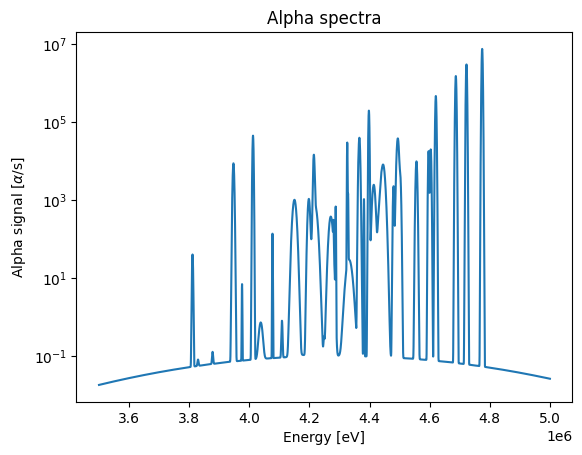

In [4]:
#Introducing alpha spectra and make sure to it is possible to calculate with the to data sets
alpha_decays, mass, nuclide_amount = an.alpha_decay_values_from_material(mat)
alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=None)


fig, ax = plt.subplots()
ax.plot(energies,alpha_spectra)
ax.semilogy()
ax.set_title('Alpha spectra')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'Alpha signal [$\alpha$/s]')




mt alpha reactions: 4=n', 16=2n, 17=3n, 22=n+a
23=n+3a, 24=2n+a, 25=3n+a, 28=n+p and 29=n+2a


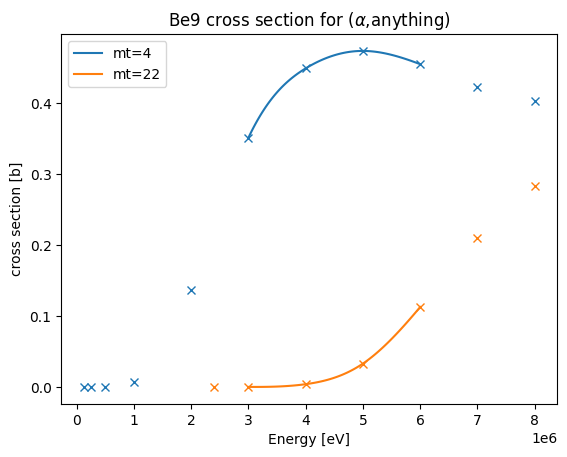

In [78]:
#Loading cross sections
from openmc.data.endf import Evaluation, get_head_record, get_tab1_record
from io import StringIO
from scipy.interpolate import make_interp_spline
from scipy import integrate

#Also possible with .tendl files seems jendl is better but tendl is more exstensive

def get_crosssection_spline(nuc_name, mt,k=1, xs=None, x_min=2e6, x_max=8e6):
    #Getting data
    symbol,Z,A = an.isolate_atomic_symbol(nuc_name)
    ev = Evaluation(f"/root/TENDL-a/a-{symbol}{A}.tendl")
    
    mf=3 #Reaction cross sections
    try:
        endf_output = StringIO(ev.section[mf,mt])
    except:
        #print(f'mt={mt} does not exist')
        return None,None, None
    head = get_head_record(endf_output)
    params, tab = get_tab1_record(endf_output)
    #print('energy',tab.x)   # energies in eV
    #print('cross section',tab.y)   # cross sections in barns

    #Removing data under x_min, over x_max and duplicates 
    mask = (tab.x >= x_min) & (tab.x <= x_max)
    tab.x = tab.x[mask]
    tab.y = tab.y[mask]
    if len(tab.x) ==0:
        #print(f'no data between {x_min} eV and {x_max} eV')
        return None,None,None
    tab.x, idx = np.unique(tab.x, return_index=True)
    tab.y = tab.y[idx]

    if xs is None:
        xs = np.linspace(min(tab.x),max(tab.x),int(1e4))
    while k>0:    
        try:    
            spline = make_interp_spline(tab.x,tab.y,k=k)
            break
        except:
            k-=1
            if k==1:
                spline = make_interp_spline(tab.x,tab.y,k=k)
    return spline, tab, xs

def get_crossection_from_isotope(nuc_name,k=1,xs=None, x_min=0, x_max=8e6, plot=True,print_no_data=False):
    splines={}
    tabs={}
    failed_mts = []
    if plot:
        fig,ax = plt.subplots()
        ax.set_title(rf'{nuc_name} cross section for ($\alpha$,anything)')
        ax.set_xlabel('Energy [eV]')
        ax.set_ylabel(r'cross section [b]')
    
    for mt in np.array([4,16,17,22,23,24,25,28,29]):
        mt= int(mt)
        spline, tab ,xs = get_crosssection_spline(nuc_name,mt,k,xs,x_min,x_max)
        
        if spline != None:
            splines[mt]=spline
            tabs[mt]=tab
            if plot:
                ax.plot(tab.x,tab.y,'x-',label=f'mt={mt}')
                ax.plot(xs,spline(xs))
        else:
            failed_mts.append(mt)
    if len(failed_mts)>0 and print_no_data:  
        print(f'In {nuc_name} following mts had no data',failed_mts)
    if plot:
        ax.legend()
    return splines,tabs
    
#splines = get_crossection_from_material('Be009',x_max=9e7)
nuc_cross_splines={}
nuc_cross_tabs={}
for nuc in mat.nuclides:
    splines,tabs = get_crossection_from_isotope(nuc.name,k=3,x_max=8e6,plot=False)
    nuc_cross_splines[nuc.name]=splines
    nuc_cross_tabs[nuc.name]=tabs
print('mt alpha reactions: 4=n\', 16=2n, 17=3n, 22=n+a\n23=n+3a, 24=2n+a, 25=3n+a, 28=n+p and 29=n+2a')  
nuc_name='Be9'
xs=np.linspace(3e6,6e6,100)

fig,ax = plt.subplots()
ax.set_title(rf'{nuc_name} cross section for ($\alpha$,anything)')
ax.set_xlabel('Energy [eV]')
ax.set_ylabel(r'cross section [b]')
for mt in nuc_cross_splines[nuc_name]:
    spline = nuc_cross_splines[nuc_name][mt]
    tab = nuc_cross_tabs[nuc_name][mt]
    dat_plot,=ax.plot(tab.x,tab.y,'x')
    ax.plot(xs,spline(xs),label=f'mt={mt}',color=dat_plot.get_color())

ax.legend()

energy span 3500 5000
Waiting for SRModule to produce output...
end of file
given x is used


/tmp/ipykernel_1472/200351833.py:13: RuntimeWarning: invalid value encountered in log
  return A*np.log(B*E)/E + C


Number of neutrons pr second from Fuel_A is 25.193


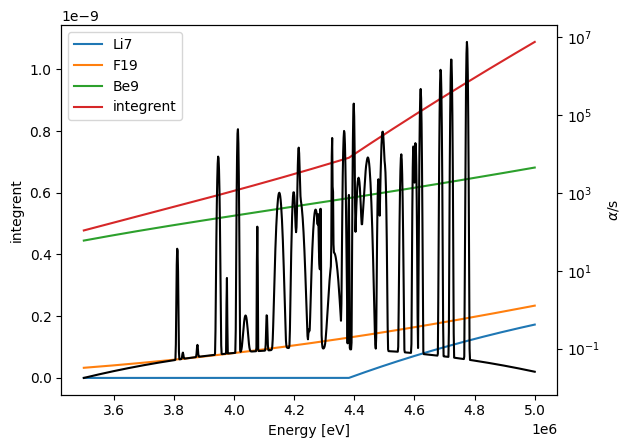

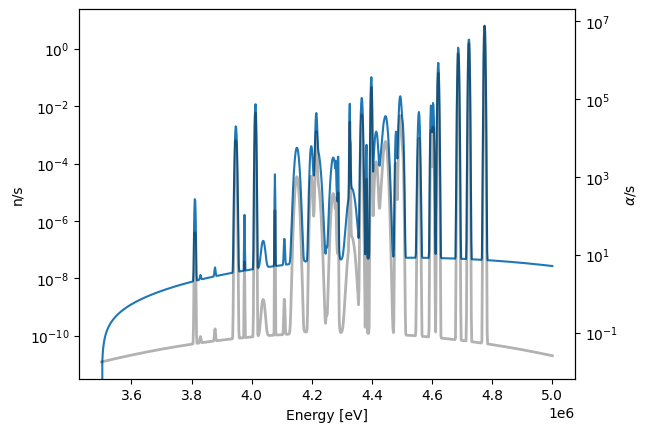

In [87]:
#Atomic density and making the basic integral

mat_dens = mat.get_nuclide_atom_densities() # in atoms/(b*cm) *1e24=atoms/cm^3

def neutrons_from_material(mat,nuclide_name,E_min=3.5e6,E_max=5e6,nr_points=1000,plot_crosssections=False):
    #Getting data
    mat_dens = mat.get_nuclide_atom_densities()

    #Stopping power
    energies,stopping_powers = an.SR_file_write_and_read(mat,E_min=int(E_min/1000),E_max=int(E_max/1000),new_file=False)
    popt, cov = curve_fit(bethe_tail,energies, stopping_powers,p0=[ 3.07e+07, 1, 0])

    energy_lin = np.linspace(E_min,E_max,nr_points)
    stopping_powers_fit = bethe_tail(energy_lin, *popt)

    #Alpha spectrum
    alpha_decays, mass,nuclide_amount = an.alpha_decay_values_from_material(mat)
    nuclide_density= nuclide_amount/mat.volume
    alpha_spectra,energies = an.energy_spectra_gaussian(alpha_decays,x=energy_lin)

    integrent = np.zeros(nr_points)
    fig, ax = plt.subplots()

    for nuc in mat.nuclides:
        #Getting crosssections
        cross_splines,tab = get_crossection_from_isotope(nuc.name,k=5,x_max=8e6,plot=False)
        total_crosssection = np.zeros(nr_points)
        for mt in cross_splines:
            #print(f'mt={mt}')
            spline_with_nan = cross_splines[mt](energy_lin, extrapolate=False)
            spline_data = np.nan_to_num(spline_with_nan,nan=0.00)
            
            if mt in [4,22,23,28,29]: #(a,n+anything)
                total_crosssection += spline_data
                
            elif mt in [11,16,24,30]: #(a,2n+anything)
                total_crosssection += 2*spline_data
                
            elif mt in [17,25]: #(a,3n+anything) for up to mt=30
                total_crosssection += 3*spline_data
            else:
                print(f'reaction with mt={mt} is not know')
                
            if nuc.name in nuclide_name and plot_crosssections and np.sum(tab[mt].y)>1e-3:
                data,=ax.plot(tab[mt].x,tab[mt].y,'x',label=f'{nuc.name}:{mt}')
                ax.plot(energy_lin,spline_data,color=data.get_color())
        #getting nuclide specific density
        target_density=nuclide_density*mat_dens[nuc_name]
        #print(f'target density: {target_density:.3g}')
        #print(target_density*total_crosssection/stopping_powers_fit)
    
        #Making integrent
        if np.sum(total_crosssection)>1e-5:
            ax.plot(energy_lin,target_density*total_crosssection/stopping_powers_fit*1e-24,label=f'{nuc.name}')
        integrent += target_density*total_crosssection/stopping_powers_fit*1e-24

    dx=(E_max-E_min)/nr_points
    neutrons_total = 0
    neutrons_added = []
    for E_a,alpha,n in zip(energy_lin,alpha_spectra,range(nr_points)):
        if n>1:
            neutrons = alpha*integrate.simpson(integrent[0:n],energy_lin[0:n])/nr_points
            neutrons_total +=neutrons
            neutrons_added.append(neutrons)
        else:
            neutrons_added.append(0)
    fig2,ax2 = plt.subplots()
    ax3=ax2.twinx()

    ax2.plot(energy_lin,neutrons_added,label='n')
    ax3.plot(energy_lin,alpha_spectra,label='spectra',color='k',lw=2,alpha=0.3)
    
    ax2.set_xlabel('Energy [eV]')
    ax3.semilogy()
    ax2.semilogy()
    ax3.set_ylabel(r'$\alpha$/s')
    ax2.set_ylabel('n/s')
    
    #ax.plot(energy_lin,stopping_powers_fit,label='stopping_power')
    #ax.plot(energy_lin,total_crosssection,label='cross_section')
    ax.plot(energy_lin,integrent,label='integrent')

    ax1 = ax.twinx()
    ax1.plot(energy_lin,alpha_spectra,label='spectra',color='k')
    ax1.semilogy()
    ax.set_ylabel('integrent')
    ax1.set_ylabel(r'$\alpha$/s')
    ax.set_xlabel('Energy [eV]')
    ax.legend()
    
    return neutrons_total

nuclide_names=[nuc.name for nuc in mat.nuclides]
neutrons = neutrons_from_material(mat,nuclide_names,nr_points=2**10+1,plot_crosssections=False)
print(f'Number of neutrons pr second from {mat.name} is {neutrons:.5g}')